<a href="https://colab.research.google.com/github/BrunaLimaa/ImgSegmentation-IC/blob/SDUAISHD/notebooks/08_modular_distances.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Attempting to retrieve or calculate the galaxy distance in parsecs inside the function.

# DEPENDENCIES

In [ ]:
!pip install astropy
!pip install astrodendro
!pip install sep
!pip install photutils
!pip install astroquery


In [ ]:
import numpy as np
from astropy.io import fits
import sep
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from photutils.isophote import EllipseGeometry, Ellipse
from astroquery.ipac.ned import Ned
from astroquery.simbad import Simbad
from astropy import units as u

# FUNCTIONS

In [ ]:

def display_image(fileImage):

  hdul = fits.open(fileImage, ignore_missing_simple=True)
  data = hdul[0].data

  image_data = data.astype(float)

  good_pixel_mask = ~np.logical_or(np.isnan(image_data), image_data <= 0)
  norm = simple_norm(image_data[good_pixel_mask], stretch='log', percent=95.5)

  fig, axes = plt.subplots(figsize=(10, 10))
  im = axes.imshow(image_data, cmap='gray_r', origin='lower', norm=norm)
  fig.colorbar(im, label="Pixel Brightness (Log Scale)", shrink=0.78, aspect=10)
  plt.show()

In [ ]:
def get_galaxy_distance(bar_length_pixels):
  pixel_length = bar_length_pixels

  plate_scale = 0.25 #how much one pixel covers in arcseconds
  distance_to_galaxy = 18800000 # distance of NGC 1300 specifically.
  angular_size_arcsec = pixel_length * plate_scale #total size of the bar on the sky. how much space it takes up. Also in arcseconds

  angular_size_radians = np.deg2rad(angular_size_arcsec / 3600)#arcseconds to radians

  bar_size_parsecs = distance_to_galaxy * angular_size_radians# distance in parsecs.

  print(f"Galaxy Distance: {distance_to_galaxy} parsecs")
  print(f"Pixel Length:    {pixel_length} pixels")
  print(f"Angular Size:    {angular_size_arcsec:.2f} arcseconds")
  print(f"Bar Size:        {bar_size_parsecs:.0f} parsecs")

In [ ]:
def get_bar_length_pixels(fileImage):
  hdul = fits.open(fileImage)
  image_data = hdul[0].data.astype(float)
  hdul.close()

  image_data[np.isnan(image_data)] = 0.0

  # gets the exact center of the picture. So the middle of the bar must the in the center!!
  ny, nx = image_data.shape
  x_center = nx // 2
  y_center = ny // 2

  print(f"Image dimensions: {nx}x{ny}. Using center at ({x_center}, {y_center})")

  #define the shape as an ellipse
  g = EllipseGeometry(x0=x_center, y0=y_center, sma=10.0, eps=0.2, pa=0.0)

  # measures image using the shape we just created.
  ellipse = Ellipse(image_data, geometry=g)

  try:
      # add 'maxsma=450' to stop it from going to the noisy edge
      # this parameter should be calculated somehow, so the script works for other galaxies.
      isolist = ellipse.fit_image(maxsma=450)
      print(f"Successfully fit {len(isolist)} isophotes.")
  except Exception as e:
      print(f"Error: Isophote fit failed. {e}")


  if 'isolist' in locals() and len(isolist) > 1:
      plt.figure(figsize=(10, 6))

      # x is the size of each ellipse
      #y is the ovalness of each ellipse
      plt.plot(isolist.sma, isolist.eps, 'bo-')


      plt.xlabel('Radius (Semi-Major Axis in pixels)')
      plt.ylabel('Ellipticity (eps)')
      plt.title('Ellipticity Profile of NGC 1300')

      # ignore all the measurements smaller than 10 pixels
      valid_fits = isolist.sma > 100

      # out of the valid ellipses, we take only the biggest one. that'll be the radius
      # the major axis
      bar_radius_pixels = isolist.sma[valid_fits][np.argmax(isolist.eps[valid_fits])]
      print(f"Bar found! Peak ellipticity is at radius = {bar_radius_pixels:.2f} pixels")

      # The bar's length is 2 * its radius
      bar_length_pixels = 2 * bar_radius_pixels

      plt.show()

      return bar_length_pixels

  else:
      print("Fit failed, no plot to show.")

# RESULTS

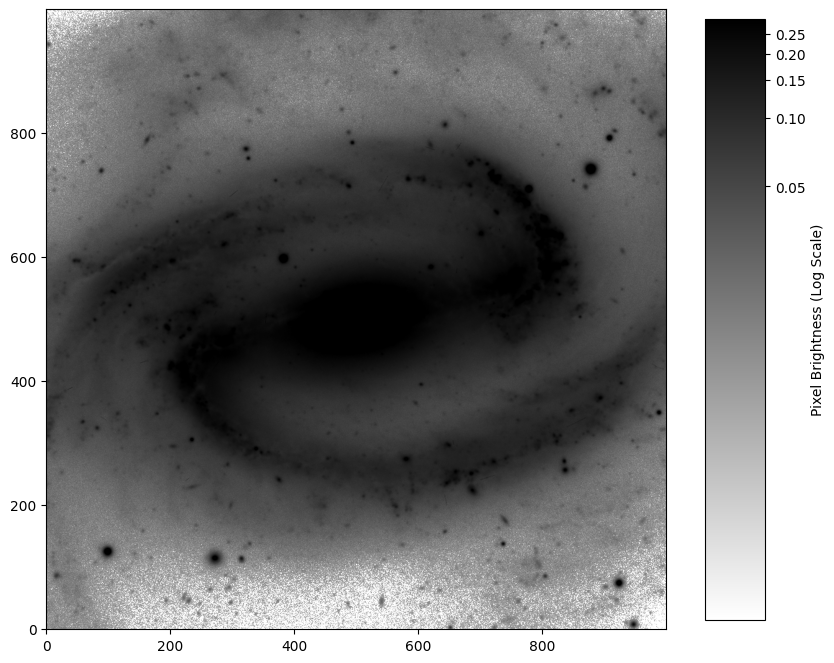

Image dimensions: 1000x1000. Using center at (500, 500)
Successfully fit 72 isophotes.
Bar found! Peak ellipticity is at radius = 309.13 pixels


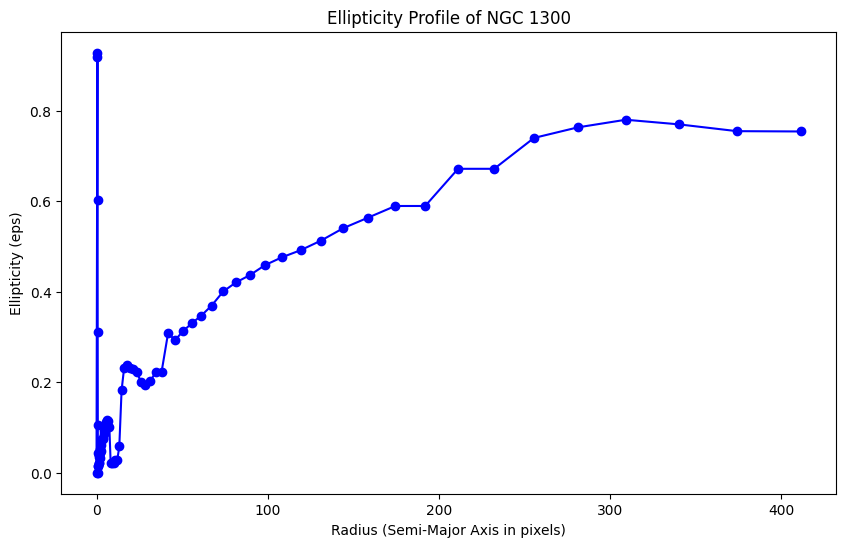

Galaxy Distance: 18800000 parsecs
Pixel Length:    618.2536106574153 pixels
Angular Size:    154.56 arcseconds
Bar Size:        14088 parsecs


In [ ]:
originalImage = "NGC-1300.fits"

display_image(originalImage)
bar_length = get_bar_length_pixels(originalImage)
get_galaxy_distance(bar_length)

In [ ]:

def get_galaxy_distance_robust(galaxy_name):
    print(f"--- Analyzing {galaxy_name} ---")

    try:
        # redshift independent table
        dist_table = Ned.get_table(galaxy_name, table='redshift_independent_dist')

        # calculate the average
        if len(dist_table) > 0:

            # check for the 'D' column (Distance in Mpc)
            if 'D' in dist_table.colnames:
                mean_dist_mpc = np.nanmean(dist_table['D'])
                dist_parsecs = mean_dist_mpc * 1_000_000
                print(f"Method: NED Direct Measurement (Mean of {len(dist_table)} records)")
                print(f"Distance found: {dist_parsecs:.0f} parsecs")
                return dist_parsecs

    except Exception as e:
        print(f"Strategy 1 failed (No direct distance table found).")

    # STRATEGY 2, use NED for Hubble's law.
    try:

        result_table = Ned.query_object(galaxy_name)

        # get the velocity for the formula
        if 'Velocity' in result_table.colnames:
            velocity_kms = result_table['Velocity'][0]

            # Hubble Constant
            H0 = 70.0

            dist_mpc = velocity_kms / H0
            dist_parsecs = dist_mpc * 1_000_000

            print(f"Method: Calculated from NED Velocity ({velocity_kms:.0f} km/s)")
            print(f"Result: {dist_parsecs:.0f} parsecs")
            return dist_parsecs
        else:
            print("Error: 'Velocity' column missing from NED result.")

    except Exception as e:
        print(f"Strategy 2 failed: {e}")

distance_to_galaxy = get_galaxy_distance_robust("NGC 1300")

--- Analyzing NGC 1300 ---
Strategy 1 failed (No direct distance table found).
Attempting Strategy 2 (Velocity Calculation)...
Method: Calculated from NED Velocity (1578 km/s)
Result: 22542857 parsecs
